In [1]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Dataset_CitizenGrivences/BBMP_grievance_data_2025.csv")

In [2]:
df = df[["Sub Category", "Category"]]
df = df.rename(columns={
    "Sub Category" : "Text",
    "Category" : "Department"
 })

# **Checking/Inspecting the data, and getting familiar with the dataset**

In [3]:
df["Text"].head()

,Text
0,Street Light Not Working
1,Street Light Not Working
2,Garbage dump
3,Street Light Not Working
4,Garbage dump


In [4]:
df["Department"].value_counts().head(10)

,count
Department,
Electrical,42138
Solid Waste (Garbage) Related,38151
Road Maintenance(Engg),14124
veterinary,7677
Forest,6325
E khata / Khata services,4190
Health Dept,3378
Road Infrastructure,2662
Others,2066


In [5]:
df.shape

(126974, 2)

In [6]:
df.isnull().sum()

,0
Text,0
Department,0


# **Cleaning data by removing stop words and lemmatization**

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Text'].apply(clean_text)
df[['Text','clean_text']].head()

,Text,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


# **Generating word cloud visualiztion for complaint data**

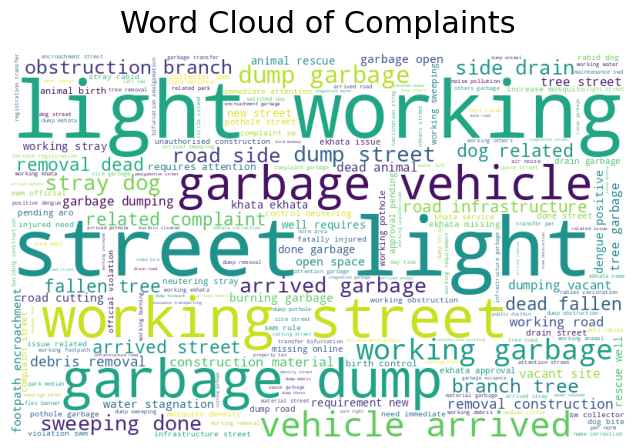

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])
wc = WordCloud(width=800, height=500, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.title("Word Cloud of Complaints", fontsize=22, pad=15)
plt.axis('off')
plt.show()

# **Extracting N-grams frequency**

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# bigrams
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(df['clean_text'])

sum_words = X.sum(axis=0)

words_freq = []
for word, idx in vectorizer.vocabulary_.items():
    count = int(sum_words[0, idx])
    words_freq.append((word, count))

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:20]

[('street light', 41570),
 ('light working', 40109),
 ('garbage dump', 16137),
 ('garbage vehicle', 12135),
 ('vehicle arrived', 12135),
 ('stray dog', 4115),
 ('sweeping done', 3641),
 ('road side', 3269),
 ('side drain', 3269),
 ('obstruction branch', 3161),
 ('branch tree', 3161),
 ('related complaint', 3022),
 ('removal dead', 2884),
 ('dead fallen', 2884),
 ('fallen tree', 2884),
 ('dog related', 2775),
 ('road infrastructure', 2662),
 ('debris removal', 1900),
 ('removal construction', 1900),
 ('construction material', 1900)]

# **Saving cleaned data**

In [13]:
df.to_csv("cleaned_data.csv", index=False)

# **Week 1 Done**